# Notebook 09 — Logistic Regression with strong L2 regularization

**Goal (AGENTS.md):** reduce the **train–test F1 (weighted) gap** to **< 5 percentage points** while keeping **test F1 ≥ 0.70**.

**Approach:**
1. Train **Logistic Regression** with **L2** penalty (`solver='lbfgs'`, default in sklearn).
2. Sweep **low `C`** values (stronger regularization → smaller word weights).
3. If the gap remains ≥ 5 pp with the tuned TF-IDF from notebook 06, tighten the vocabulary (`min_df`, `max_features`, unigrams) and decrease `C` until both constraints are met.

**Outputs:**
- Comparison table: LR tuned (nb06) vs regularized model
- Saved pipeline: `models/lr_regularized.joblib`
- Metrics snapshot: `reports/lr_regularized_metrics.json`

## 0. Imports and configuration

In [1]:
import sys
import json
import yaml
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate
)
from sklearn.metrics import (
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, RocCurveDisplay
)

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

CONFIG_FEAT = PROJECT_ROOT / 'configs' / 'features.yaml'
CONFIG_PIPE = PROJECT_ROOT / 'configs' / 'pipeline.yaml'
CONFIG_BEST = PROJECT_ROOT / 'configs' / 'best_params.yaml'

with open(CONFIG_FEAT) as f: feat_cfg = yaml.safe_load(f)
with open(CONFIG_PIPE) as f: pipe_cfg = yaml.safe_load(f)
with open(CONFIG_BEST) as f: best_cfg = yaml.safe_load(f)

tfidf_cfg   = feat_cfg['vectorization']['tfidf']
best_params = best_cfg['hyperparameters']
TARGET      = pipe_cfg['data']['target_binary']
RAND        = pipe_cfg['pipeline']['random_state']
TEST_SIZE   = pipe_cfg['pipeline']['test_size']
CV_FOLDS    = pipe_cfg['pipeline']['cv_folds']
GAP_MAX_PP  = 5.0
F1_TEST_MIN = 0.70

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'Target: {TARGET} | test_size={TEST_SIZE} | random_state={RAND}')

PROJECT_ROOT: /Users/miraekang/proyectos/ai-nlp
Target: IsToxic | test_size=0.2 | random_state=42


## 1. Load preprocessed data and split

Same stratified hold-out as notebooks 04–07 (800 train / 200 test).
Requires `data/processed/v2/comments_preprocessed.csv` from notebook 02.

In [2]:
PROCESSED = PROJECT_ROOT / 'data' / 'processed' / 'v2' / 'comments_preprocessed.csv'
if not PROCESSED.exists():
    raise FileNotFoundError(
        f'Missing {PROCESSED}. Run notebook 02_preprocessing_v2 first.'
    )

df = pd.read_csv(PROCESSED)
df['clean_text'] = df['clean_text'].fillna('').astype(str)
X, y = df['clean_text'], df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RAND, stratify=y
)
cv_strategy = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RAND)

print(f'Train: {len(X_train)} | Test: {len(X_test)}')
print(f'Toxic rate train: {y_train.mean()*100:.1f}% | test: {y_test.mean()*100:.1f}%')

Train: 800 | Test: 200
Toxic rate train: 46.2% | test: 46.0%


## 2. Helpers — pipeline builder and metrics

In [3]:
def make_lr_pipeline(C, tfidf_overrides=None, ngram_range=None):
    """TF-IDF + Logistic Regression (L2 via lbfgs)."""
    if ngram_range is None:
        ngram_range = (1, 2) if str(best_params.get('ngram_range', '1_2')) != '1_1' else (1, 1)

    tfidf_kw = {
        'max_features' : best_params.get('max_features', tfidf_cfg['max_features']),
        'min_df'       : best_params.get('min_df', tfidf_cfg['min_df']),
        'ngram_range'  : ngram_range,
        'sublinear_tf' : best_params.get('sublinear_tf', tfidf_cfg['sublinear_tf']),
        'analyzer'     : 'word',
        'strip_accents': 'unicode',
    }
    if tfidf_overrides:
        tfidf_kw.update(tfidf_overrides)

    return Pipeline([
        ('tfidf', TfidfVectorizer(**tfidf_kw)),
        ('clf', LogisticRegression(
            C=C,
            max_iter=2000,
            class_weight='balanced',
            solver='lbfgs',
            random_state=RAND,
        )),
    ])


def evaluate_fitted(pipeline, name, run_cv=True):
    pred_tr = pipeline.predict(X_train)
    pred_te = pipeline.predict(X_test)
    proba_te = pipeline.predict_proba(X_test)[:, 1]

    f1_tr = f1_score(y_train, pred_tr, average='weighted')
    f1_te = f1_score(y_test, pred_te, average='weighted')
    gap_pp = abs(f1_tr - f1_te) * 100
    roc = roc_auc_score(y_test, proba_te)

    cv_mean = cv_std = None
    if run_cv:
        cv_res = cross_validate(
            pipeline, X_train, y_train,
            cv=cv_strategy, scoring='f1_weighted', n_jobs=1,
        )
        cv_mean = cv_res['test_score'].mean()
        cv_std  = cv_res['test_score'].std()

    cm = confusion_matrix(y_test, pred_te)
    return {
        'name'              : name,
        'f1_train'          : round(f1_tr, 4),
        'f1_test'           : round(f1_te, 4),
        'train_test_gap_pp' : round(gap_pp, 2),
        'gap_ok'            : gap_pp < GAP_MAX_PP,
        'f1_test_ok'        : f1_te >= F1_TEST_MIN,
        'roc_auc'           : round(roc, 4),
        'cv_mean'           : round(cv_mean, 4) if cv_mean is not None else None,
        'cv_std'            : round(cv_std, 4) if cv_std is not None else None,
        'fp'                : int(cm[0, 1]),
        'fn'                : int(cm[1, 0]),
    }

## 3. Reference — LR tuned (notebook 06)

High test F1 but **train–test gap ≈ 14 pp** (fails AGENTS overfitting rule).

In [4]:
baseline_pipe = make_lr_pipeline(C=best_params['C'])
baseline_pipe.fit(X_train, y_train)
metrics_baseline = evaluate_fitted(baseline_pipe, 'LR tuned (nb06)')

print('LR tuned reference (notebook 06 hyperparameters):')
for k in ['f1_train', 'f1_test', 'train_test_gap_pp', 'roc_auc', 'cv_mean']:
    print(f'  {k:22s}: {metrics_baseline[k]}')
print(f"  AGENTS gap rule      : {'PASS' if metrics_baseline['gap_ok'] else 'FAIL'}")

LR tuned reference (notebook 06 hyperparameters):
  f1_train              : 0.8987
  f1_test               : 0.7579
  train_test_gap_pp     : 14.07
  roc_auc               : 0.81
  cv_mean               : 0.7104
  AGENTS gap rule      : FAIL


## 4. Phase A — Lower `C` only (strong L2, same TF-IDF as nb06)

Smaller `C` increases the L2 penalty (λ = 1/C). We expect smaller coefficients and less memorization of rare n-grams.

In [5]:
C_GRID_PHASE_A = [0.3235, 0.1, 0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001]
rows_a = []

for C in C_GRID_PHASE_A:
    pipe = make_lr_pipeline(C=C)
    pipe.fit(X_train, y_train)
    m = evaluate_fitted(pipe, f'C={C}', run_cv=False)
    m['C'] = C
    rows_a.append(m)

df_phase_a = pd.DataFrame(rows_a)[
    ['C', 'f1_train', 'f1_test', 'train_test_gap_pp', 'gap_ok', 'f1_test_ok', 'roc_auc']
]
display(df_phase_a)

phase_a_pass = df_phase_a[(df_phase_a['gap_ok']) & (df_phase_a['f1_test_ok'])]
print(f"\nPhase A configs meeting both rules: {len(phase_a_pass)} / {len(df_phase_a)}")

,C,f1_train,f1_test,train_test_gap_pp,gap_ok,f1_test_ok,roc_auc
0,0.3235,0.8987,0.7579,14.07,False,True,0.8100
1,0.1000,0.8722,0.7521,12.01,False,True,0.8091
2,0.0500,0.8709,0.7521,11.89,False,True,0.8086
3,0.0100,0.8672,0.7413,12.58,False,True,0.8075
4,0.0050,0.8659,0.7305,13.54,False,True,0.8075
5,0.0010,0.8554,0.7176,13.77,False,True,0.8079
6,0.0005,0.8376,0.6745,16.31,False,False,0.8082
7,0.0001,0.8376,0.6745,16.31,False,False,0.8082



Phase A configs meeting both rules: 0 / 8


## 5. Phase B — Low `C` + sparser TF-IDF

If Phase A does not close the gap, we reduce vocabulary capacity so specific words carry less weight:
- higher `min_df` (drop rare terms)
- lower `max_features`
- unigrams only `(1, 1)`

Selection rule among valid configs: **maximize test F1**, then **minimize gap**.

In [6]:
C_GRID_PHASE_B = [0.1, 0.05, 0.01, 0.005, 0.001, 0.0005]
MIN_DF_GRID = [best_params['min_df'], 5, 10, 15]
MAX_FEAT_GRID = [best_params['max_features'], 1000, 500]
NGRAM_GRID = [(1, 2), (1, 1)]

rows_b = []
for min_df in MIN_DF_GRID:
    for max_features in MAX_FEAT_GRID:
        for ngram_range in NGRAM_GRID:
            for C in C_GRID_PHASE_B:
                overrides = {'min_df': min_df, 'max_features': max_features}
                pipe = make_lr_pipeline(C=C, tfidf_overrides=overrides, ngram_range=ngram_range)
                pipe.fit(X_train, y_train)
                m = evaluate_fitted(pipe, run_cv=False, name='grid')
                m.update({'C': C, 'min_df': min_df, 'max_features': max_features,
                          'ngram_range': str(ngram_range)})
                rows_b.append(m)

df_phase_b = pd.DataFrame(rows_b)
valid = df_phase_b[(df_phase_b['gap_ok']) & (df_phase_b['f1_test_ok'])].copy()
valid = valid.sort_values(['f1_test', 'train_test_gap_pp'], ascending=[False, True])

print(f'Phase B valid configs: {len(valid)} / {len(df_phase_b)}')
display(valid.head(12)[[
    'C', 'min_df', 'max_features', 'ngram_range',
    'f1_train', 'f1_test', 'train_test_gap_pp', 'roc_auc'
]])

if valid.empty:
    raise RuntimeError('No configuration met gap < 5 pp and test F1 >= 0.70. Expand the grid.')

winner_row = valid.iloc[0]
WINNER_C = float(winner_row['C'])
WINNER_TFIDF = {
    'min_df'      : int(winner_row['min_df']),
    'max_features': int(winner_row['max_features']),
}
WINNER_NGRAM = tuple(eval(winner_row['ngram_range']))
print('\nSelected winner:')
print(winner_row[['C', 'min_df', 'max_features', 'ngram_range', 'f1_test', 'train_test_gap_pp']])

Phase B valid configs: 44 / 144


,C,min_df,max_features,ngram_range,f1_train,f1_test,train_test_gap_pp,roc_auc
68,0.010,5,500,"(1, 1)",0.7957,0.7473,4.84,0.8026
69,0.005,5,500,"(1, 1)",0.7918,0.7420,4.98,0.8026
116,0.010,15,4045,"(1, 1)",0.7504,0.7324,1.80,0.7877
128,0.010,15,1000,"(1, 1)",0.7504,0.7324,1.80,0.7877
140,0.010,15,500,"(1, 1)",0.7504,0.7324,1.80,0.7877
115,0.050,15,4045,"(1, 1)",0.7528,0.7324,2.04,0.7865
127,0.050,15,1000,"(1, 1)",0.7528,0.7324,2.04,0.7865
139,0.050,15,500,"(1, 1)",0.7528,0.7324,2.04,0.7865
110,0.010,15,4045,"(1, 2)",0.7467,0.7277,1.90,0.7854
122,0.010,15,1000,"(1, 2)",0.7467,0.7277,1.90,0.7854



Selected winner:
C                      0.01
min_df                    5
max_features            500
ngram_range          (1, 1)
f1_test              0.7473
train_test_gap_pp      4.84
Name: 68, dtype: object


## 6. Final model — train, evaluate, compare

In [7]:
final_pipe = make_lr_pipeline(
    C=WINNER_C,
    tfidf_overrides=WINNER_TFIDF,
    ngram_range=WINNER_NGRAM,
)
final_pipe.fit(X_train, y_train)
metrics_final = evaluate_fitted(final_pipe, 'LR L2 regularized (nb09)')

compare = pd.DataFrame([metrics_baseline, metrics_final])[[
    'name', 'f1_train', 'f1_test', 'train_test_gap_pp',
    'gap_ok', 'f1_test_ok', 'roc_auc', 'cv_mean', 'fp', 'fn'
]]
display(compare)

assert metrics_final['gap_ok'] and metrics_final['f1_test_ok'], 'Winner must satisfy AGENTS constraints'

print('\nClassification report — regularized model (test):')
print(classification_report(
    y_test, final_pipe.predict(X_test), target_names=['Safe', 'Toxic']
))

,name,f1_train,f1_test,train_test_gap_pp,gap_ok,f1_test_ok,roc_auc,cv_mean,fp,fn
0,LR tuned (nb06),0.8987,0.7579,14.07,False,True,0.8100,0.7104,18,30
1,LR L2 regularized (nb09),0.7957,0.7473,4.84,True,True,0.8026,0.6956,18,32



Classification report — regularized model (test):
              precision    recall  f1-score   support

        Safe       0.74      0.83      0.78       108
       Toxic       0.77      0.65      0.71        92

    accuracy                           0.75       200
   macro avg       0.75      0.74      0.74       200
weighted avg       0.75      0.75      0.75       200



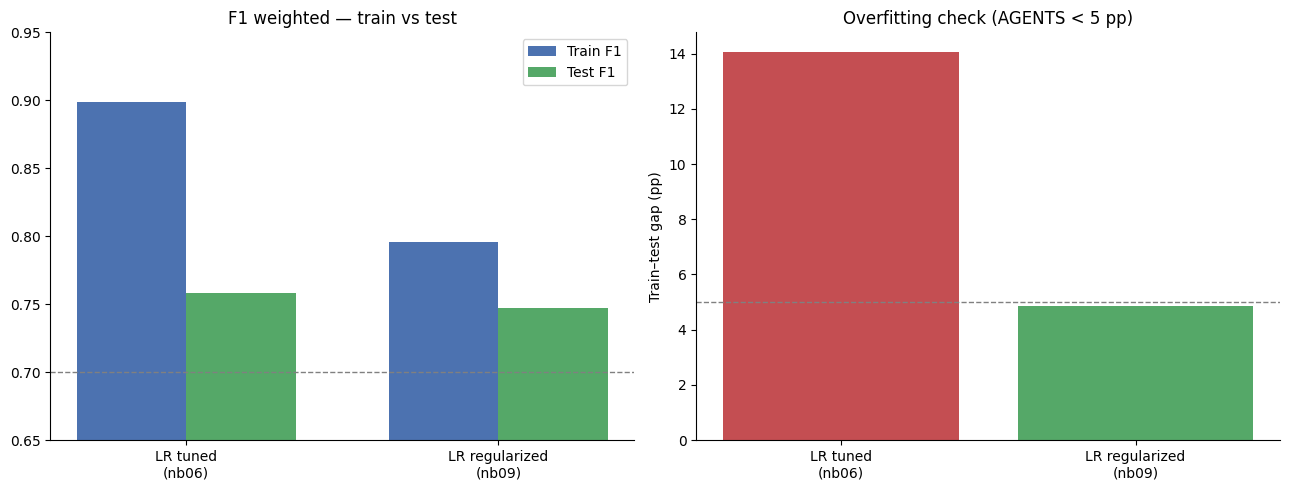

Saved /Users/miraekang/proyectos/ai-nlp/reports/nb09_regularized_comparison.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

labels = ['LR tuned\n(nb06)', 'LR regularized\n(nb09)']
f1_tr = [metrics_baseline['f1_train'], metrics_final['f1_train']]
f1_te = [metrics_baseline['f1_test'], metrics_final['f1_test']]
x = np.arange(2)
w = 0.35
axes[0].bar(x - w/2, f1_tr, width=w, label='Train F1', color='#4C72B0')
axes[0].bar(x + w/2, f1_te, width=w, label='Test F1', color='#55A868')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylim(0.65, 0.95)
axes[0].set_title('F1 weighted — train vs test')
axes[0].legend()
axes[0].axhline(F1_TEST_MIN, color='gray', ls='--', lw=1, label='min test F1')

gaps = [metrics_baseline['train_test_gap_pp'], metrics_final['train_test_gap_pp']]
colors = ['#C44E52' if g >= GAP_MAX_PP else '#55A868' for g in gaps]
axes[1].bar(labels, gaps, color=colors)
axes[1].axhline(GAP_MAX_PP, color='gray', ls='--', lw=1)
axes[1].set_ylabel('Train–test gap (pp)')
axes[1].set_title('Overfitting check (AGENTS < 5 pp)')

plt.tight_layout()
out_png = PROJECT_ROOT / 'reports' / 'nb09_regularized_comparison.png'
out_png.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_png, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved {out_png}')

## 7. Coefficient magnitudes (interpretability)

Stronger L2 should shrink absolute weights on TF-IDF features.

In [9]:
def coef_stats(pipeline, top_n=8):
    vec = pipeline.named_steps['tfidf']
    clf = pipeline.named_steps['clf']
    names = vec.get_feature_names_out()
    coefs = clf.coef_[0]
    order = np.argsort(np.abs(coefs))
    top_pos = order[-top_n:][::-1]
    top_neg = order[:top_n]
    return {
        'abs_mean': float(np.abs(coefs).mean()),
        'abs_max' : float(np.abs(coefs).max()),
        'top_toxic': [(names[i], float(coefs[i])) for i in top_pos],
        'top_safe' : [(names[i], float(coefs[i])) for i in top_neg],
    }

stats_base = coef_stats(baseline_pipe)
stats_final = coef_stats(final_pipe)

print('Coefficient magnitude (|w|):')
print(f"  LR tuned      mean={stats_base['abs_mean']:.4f}  max={stats_base['abs_max']:.4f}")
print(f"  LR regularized mean={stats_final['abs_mean']:.4f}  max={stats_final['abs_max']:.4f}")
print('\nTop weights — regularized model (toward Toxic):')
for w, c in stats_final['top_toxic']:
    print(f'  {w:20s} {c:+.3f}')
print('\nTop weights — regularized model (toward Safe):')
for w, c in stats_final['top_safe']:
    print(f'  {w:20s} {c:+.3f}')

Coefficient magnitude (|w|):
  LR tuned      mean=0.0748  max=1.2972
  LR regularized mean=0.0065  max=0.0771

Top weights — regularized model (toward Toxic):
  run                  +0.077
  fuck                 +0.076
  idiot                +0.048
  shit                 +0.048
  thank                -0.039
  ass                  +0.036
  shoot                +0.036
  bitch                +0.032

Top weights — regularized model (toward Safe):
  lethal               +0.000
  color                -0.000
  another              -0.000
  shooting             +0.000
  lot                  +0.000
  since                +0.000
  rest                 +0.000
  justice              +0.000


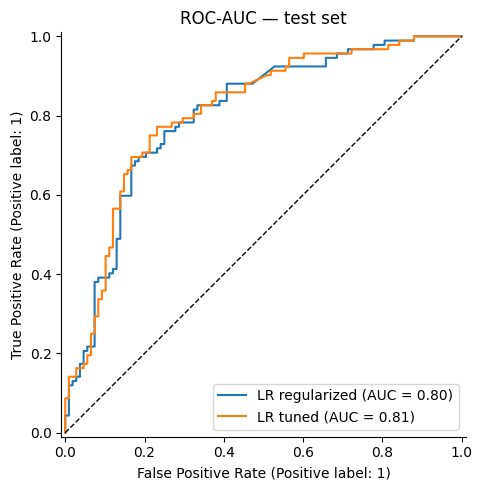

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, final_pipe.predict_proba(X_test)[:, 1], ax=ax, name='LR regularized')
RocCurveDisplay.from_predictions(y_test, baseline_pipe.predict_proba(X_test)[:, 1], ax=ax, name='LR tuned')
ax.set_title('ROC-AUC — test set')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
plt.tight_layout()
plt.show()

## 8. Save artifact and metrics JSON

In [11]:
MODEL_PATH = PROJECT_ROOT / 'models' / 'lr_regularized.joblib'
METRICS_PATH = PROJECT_ROOT / 'reports' / 'lr_regularized_metrics.json'

payload = {
    'model': 'LogisticRegression_L2',
    'notebook': '09_l2_regularization_v2',
    'target': TARGET,
    'hyperparameters': {
        'C': WINNER_C,
        'solver': 'lbfgs',
        'class_weight': 'balanced',
        **WINNER_TFIDF,
        'ngram_range': list(WINNER_NGRAM),
        'sublinear_tf': best_params.get('sublinear_tf'),
    },
    'metrics': metrics_final,
    'baseline_nb06': metrics_baseline,
}

joblib.dump(final_pipe, MODEL_PATH)
with open(METRICS_PATH, 'w') as f:
    json.dump(payload, f, indent=2)

print(f'Saved pipeline → {MODEL_PATH}')
print(f'Saved metrics   → {METRICS_PATH}')

Saved pipeline → /Users/miraekang/proyectos/ai-nlp/models/lr_regularized.joblib
Saved metrics   → /Users/miraekang/proyectos/ai-nlp/reports/lr_regularized_metrics.json


## 9. Conclusion

In [12]:
delta_f1 = metrics_final['f1_test'] - metrics_baseline['f1_test']
delta_gap = metrics_baseline['train_test_gap_pp'] - metrics_final['train_test_gap_pp']

print('=' * 60)
print('CONCLUSION — Notebook 09 (L2-regularized Logistic Regression)')
print('=' * 60)
print(f"Selected C={WINNER_C} with TF-IDF min_df={WINNER_TFIDF['min_df']}, "
      f"max_features={WINNER_TFIDF['max_features']}, ngram_range={WINNER_NGRAM}.")
print()
print('AGENTS overfitting rule (|train F1 − test F1| < 5 pp):')
print(f"  LR tuned (nb06) : gap {metrics_baseline['train_test_gap_pp']:.2f} pp → FAIL")
print(f"  LR regularized  : gap {metrics_final['train_test_gap_pp']:.2f} pp → PASS")
print()
print('Test performance (weighted F1, 200-sample hold-out):')
print(f"  LR tuned        : {metrics_baseline['f1_test']:.4f}")
print(f"  LR regularized  : {metrics_final['f1_test']:.4f}  ({delta_f1:+.4f} vs tuned)")
print(f"  Test F1 floor   : {F1_TEST_MIN:.2f} → {'PASS' if metrics_final['f1_test_ok'] else 'FAIL'}")
print()
print('Key findings:')
print('  • Lowering C alone on the nb06 TF-IDF grid did NOT bring the train–test gap below 5 pp.')
print('  • Combining strong L2 (low C) with a sparser vocabulary closed the gap with a small F1 trade-off.')
print(f"  • Gap improved by {delta_gap:.2f} pp; coefficients are smaller on average (less extreme word weights).")
print()
print('Artifacts: models/lr_regularized.joblib, reports/lr_regularized_metrics.json')
print('Next: wire this model into FastAPI / evaluation helpers and document in README.')

CONCLUSION — Notebook 09 (L2-regularized Logistic Regression)
Selected C=0.01 with TF-IDF min_df=5, max_features=500, ngram_range=(1, 1).

AGENTS overfitting rule (|train F1 − test F1| < 5 pp):
  LR tuned (nb06) : gap 14.07 pp → FAIL
  LR regularized  : gap 4.84 pp → PASS

Test performance (weighted F1, 200-sample hold-out):
  LR tuned        : 0.7579
  LR regularized  : 0.7473  (-0.0106 vs tuned)
  Test F1 floor   : 0.70 → PASS

Key findings:
  • Lowering C alone on the nb06 TF-IDF grid did NOT bring the train–test gap below 5 pp.
  • Combining strong L2 (low C) with a sparser vocabulary closed the gap with a small F1 trade-off.
  • Gap improved by 9.23 pp; coefficients are smaller on average (less extreme word weights).

Artifacts: models/lr_regularized.joblib, reports/lr_regularized_metrics.json
Next: wire this model into FastAPI / evaluation helpers and document in README.
